In [1]:
import paddlenlp
from datasets import load_dataset
train_path = "data/data175000/train.json"
dev_path = "data/data175000/dev.json"
test_path = "data/data175000/test.json"

dataset = load_dataset("json", data_files={"train":train_path, "dev":dev_path, "test":test_path})

dataset["train"][:3]

/home/ricaedo/下载/yes/envs/paddle/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/ricaedo/下载/yes/envs/paddle/lib/python3.10/site-packages/_distutils_hack/__init__.py:30: UserWarning: Setuptools is replacing distutils. Support for replacing an already imported distutils is deprecated. In the future, this condition will fail. Register concerns at https://github.com/pypa/setuptools/issues/new?template=distutils-deprecation.yml
  warnings.warn(
/home/ricaedo/下载/yes/envs/paddle/lib/python3.10/site-packages/jieba/_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


{'text': ['It does seem like this film is polarizing us. You either love it or hate it. I loved it.<br /><br />I agree with the comment(s) that said, you just gotta "feel" this one.<br /><br />Also, early in the film, Tom Cruise shows his girlfriend a painting done by Monet--an impressionist painter. Monet\'s style is to paint in little dabs so up close the painting looks like a mess, but from a distance, you can tell what the subject is. Cruise mentions that the painting has a "vanilla sky". I believe this is a hint to the moviegoer. This movie is like that impressionist painting. It\'s impressionist filmmaking! And it\'s no coincidence that the title of the movie refers to that painting.<br /><br />This is not your typical linear plot. It requires more thought. There is symbolism and there are scenes that jump around and no, you\'re not always going to be sure what\'s going on. But at the end, all is explained.<br /><br />You will need to concentrate on this movie but I think people 

In [2]:
from paddlenlp.transformers import  AutoTokenizer
def convert_example_to_feature(examples, tokenizer, max_seq_len=512, is_infer=False):
    encoded_inputs = tokenizer(examples["text"], max_seq_len=max_seq_len)
    if not is_infer:
        encoded_inputs["labels"] = [label for label in examples["label"]]
    
    return encoded_inputs
from paddlenlp.transformers import AutoModelForSequenceClassification

model_name = 'bert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(model_name)

example = {"text":["this movie is so amazing."], "label":[1]}
features = convert_example_to_feature(example, tokenizer)
print(features) 

[2026-03-01 19:13:35,985] [    INFO] - We are using (<class 'paddlenlp.transformers.bert.tokenizer.BertTokenizer'>, False) to load 'bert-base-uncased'.
[2026-03-01 19:13:35,986] [    INFO] - Already cached /home/ricaedo/.paddlenlp/models/bert-base-uncased/bert-base-uncased-vocab.txt
[2026-03-01 19:13:35,996] [    INFO] - tokenizer config file saved in /home/ricaedo/.paddlenlp/models/bert-base-uncased/tokenizer_config.json
[2026-03-01 19:13:35,997] [    INFO] - Special tokens file saved in /home/ricaedo/.paddlenlp/models/bert-base-uncased/special_tokens_map.json


{'input_ids': [[101, 2023, 3185, 2003, 2061, 6429, 1012, 102]], 'token_type_ids': [[0, 0, 0, 0, 0, 0, 0, 0]], 'labels': [1]}


/home/ricaedo/下载/yes/envs/paddle/lib/python3.10/site-packages/paddlenlp/transformers/tokenizer_utils_base.py:2538: FutureWarning: The `max_seq_len` argument is deprecated and will be removed in a future version, please use `max_length` instead.
  warnings.warn(
/home/ricaedo/下载/yes/envs/paddle/lib/python3.10/site-packages/paddlenlp/transformers/tokenizer_utils_base.py:1925: UserWarning: Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
  warnings.warn(


In [3]:
from functools import partial
max_len = 128
trans_fn = partial(convert_example_to_feature,tokenizer=tokenizer,max_seq_len=max_len)

columns = ["text", "label"]
train_dataset = dataset["train"].map(trans_fn, batched=True, remove_columns=columns)
dev_dataset = dataset["dev"].map(trans_fn, batched=True, remove_columns=columns)
test_dataset = dataset["test"].map(trans_fn, batched=True, remove_columns=columns)


Map: 100%|██████████| 12500/12500 [00:23<00:00, 539.59 examples/s]


In [4]:
from paddlenlp.data import DataCollatorWithPadding
from paddle.io import DataLoader,BatchSampler

batch_size= 4
train_sampler = BatchSampler(train_dataset, batch_size=batch_size, shuffle=True)
dev_sampler = BatchSampler(dev_dataset, batch_size=batch_size, shuffle=False)

data_collator = DataCollatorWithPadding(tokenizer)
train_loader = DataLoader(dataset=train_dataset, batch_sampler=train_sampler, collate_fn=data_collator)
dev_loader = DataLoader(dataset=dev_dataset, batch_sampler=dev_sampler, collate_fn=data_collator)
test_loader = DataLoader(dataset=test_dataset, batch_sampler=dev_sampler, collate_fn=data_collator)

for datas in train_loader:
    print(datas)
    break

{'input_ids': Tensor(shape=[4, 128], dtype=int64, place=Place(gpu:0), stop_gradient=True,
       [[101  , 1026 , 7987 , 1013 , 1028 , 1026 , 7987 , 1013 , 1028 , 2588 ,
         16228, 2026 , 10523, 1997 , 1000 , 16588, 1010 , 1000 , 2030 , 1000 ,
         1996 , 10721, 1010 , 1000 , 2030 , 3649 , 1996 , 6443 , 2024 , 4214 ,
         2023 , 2143 , 1010 , 1045 , 4999 , 2000 , 2870 , 1010 , 1000 , 2041 ,
         1997 , 2035 , 1997 , 1996 , 2919 , 5691 , 1045 , 2071 , 2031 , 2464 ,
         1010 , 2481 , 1005 , 1056 , 1045 , 2031 , 2012 , 2560 , 2464 , 2028 ,
         2008 , 2001 , 14036, 1029 , 1000 , 2130 , 2065 , 1037 , 2143 , 2003 ,
         2025 , 2092 , 2081 , 1999 , 3408 , 1997 , 3772 , 1010 , 9855 , 1010 ,
         3015 , 1010 , 2030 , 2054 , 2031 , 2017 , 1010 , 2009 , 2064 , 2012 ,
         2560 , 2022 , 4569 , 1010 , 1998 , 3568 , 4276 , 19927, 1012 , 2021 ,
         2025 , 2069 , 2003 , 2023 , 2143 , 2919 , 1999 , 6018 , 3643 , 1010 ,
         2009 , 1005 , 1055 , 11757, 1177

W0301 19:15:14.738058 14155 gpu_resources.cc:114] Please NOTE: device: 0, GPU Compute Capability: 8.9, Driver API Version: 13.0, Runtime API Version: 11.8


In [5]:
from paddlenlp.transformers import AutoModelForSequenceClassification

num_classes = 2
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_classes=num_classes)

[2026-03-01 19:15:14,758] [    INFO] - We are using <class 'paddlenlp.transformers.bert.modeling.BertForSequenceClassification'> to load 'bert-base-uncased'.
[2026-03-01 19:15:14,759] [    INFO] - Already cached /home/ricaedo/.paddlenlp/models/bert-base-uncased/model_state.pdparams
[2026-03-01 19:15:14,759] [    INFO] - Loading weights file model_state.pdparams from cache at /home/ricaedo/.paddlenlp/models/bert-base-uncased/model_state.pdparams
[2026-03-01 19:15:17,216] [    INFO] - Loaded weights file from disk, setting weights to model.
[2026-03-01 19:15:17,285] [ WARNING] - Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForSequenceClassification: ['cls.predictions.decoder_bias', 'cls.predictions.decoder_weight', 'cls.predictions.layer_norm.bias', 'cls.predictions.layer_norm.weight', 'cls.predictions.transform.bias', 'cls.predictions.transform.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you 

In [6]:
import paddle
import paddle.nn as nn

# 定义训练参数
num_epochs = 2
learning_rate = 1e-5
eval_steps = 100
log_steps = 10
save_dir = "./checkpoints"
weight_decay = 0.01
warmup_proportion = 0.1
num_training_steps = len(train_loader) * num_epochs


decay_params = [p.name for n, p in model.named_parameters() if not any(nd in n for nd in ["bias", "norm"])]

optimizer = paddle.optimizer.AdamW(learning_rate=learning_rate,
                                   parameters=model.parameters(),
                                   weight_decay=weight_decay,
                                   apply_decay_param_fun=lambda x: x in decay_params)
loss_fn = nn.CrossEntropyLoss()

metric = paddle.metric.Accuracy()

In [7]:
from tqdm.auto import tqdm

def evaluate(model, data_loader, metric):
    model.eval()
    metric.reset()
    
    with paddle.no_grad():
        for data in tqdm(data_loader, desc="[Evaluation Progression]"):
            inputs, token_type_ids, labels = data["input_ids"], data["token_type_ids"], data["labels"]
            logits = model(input_ids=inputs, token_type_ids=token_type_ids)
            correct = metric.compute(logits, labels)
            metric.update(correct)

        dev_score = metric.accumulate() 
    
    return dev_score


In [8]:
import os
def train(model):
    # 开启模型训练模式
    model.train()
    global_step = 0
    best_score = 0.
    # 记录训练过程中的loss 和 在验证集上模型评估的分数
    train_loss_record = []
    train_score_record = []
    num_training_steps = len(train_loader) * num_epochs
    # 进行num_epochs轮训练
    for epoch in range(num_epochs):
        for data in train_loader:
            inputs, token_type_ids, labels = data["input_ids"], data["token_type_ids"], data["labels"]
            # 获取模型预测
            logits = model(input_ids=inputs, token_type_ids=token_type_ids)
            loss = loss_fn(logits, labels) # 默认求mean
            train_loss_record.append((global_step, loss.item()))
            # 梯度反向传播
            loss.backward()             
            optimizer.step()
            optimizer.clear_grad()

            if global_step % log_steps == 0:
                print(f"[Train] epoch: {epoch}/{num_epochs}, step: {global_step}/{num_training_steps}, loss: {loss.item():.5f}")
            
            if global_step != 0 and (global_step % eval_steps == 0 or global_step == (num_training_steps-1)):
                dev_score = evaluate(model, dev_loader, metric)
                train_score_record.append((global_step, dev_score))
                
                model.train()
                # 如果当前指标为最优指标，保存该模型
                if dev_score > best_score:
                    print(f"[Evaluate] best accuracy performence has been updated: {best_score:.5f} --> {dev_score:.5f}")
                    best_score = dev_score
                    save_path = os.path.join(save_dir, "best.pdparams")
                    paddle.save(model.state_dict(), save_path)
                print(f"[Evaluate]  dev score: {dev_score:.5f}") 
             
            global_step += 1
    save_path = os.path.join(save_dir, "final.pdparams")
    paddle.save(model.state_dict(), save_path)
    print("[Train] Training done!")

    return train_loss_record, train_score_record

train_loss_record, train_score_record = train(model)

W0301 19:15:17.359148 14056 gpu_resources.cc:243] WARNING: device: 0. The installed Paddle is compiled with CUDNN 8.9, but CUDNN version in your machine is 8.9, which may cause serious incompatible bug. Please recompile or reinstall Paddle with compatible CUDNN version.


[Train] epoch: 0/2, step: 0/12500, loss: 0.62075
[Train] epoch: 0/2, step: 10/12500, loss: 0.82761
[Train] epoch: 0/2, step: 20/12500, loss: 0.60569
[Train] epoch: 0/2, step: 30/12500, loss: 0.70644
[Train] epoch: 0/2, step: 40/12500, loss: 0.64817
[Train] epoch: 0/2, step: 50/12500, loss: 0.50715
[Train] epoch: 0/2, step: 60/12500, loss: 0.67187
[Train] epoch: 0/2, step: 70/12500, loss: 0.51280
[Train] epoch: 0/2, step: 80/12500, loss: 0.54891
[Train] epoch: 0/2, step: 90/12500, loss: 0.61119
[Train] epoch: 0/2, step: 100/12500, loss: 0.41132


[Evaluation Progression]: 100%|██████████| 3125/3125 [00:36<00:00, 86.58it/s]


[Evaluate] best accuracy performence has been updated: 0.00000 --> 0.82320
[Evaluate]  dev score: 0.82320
[Train] epoch: 0/2, step: 110/12500, loss: 0.21958
[Train] epoch: 0/2, step: 120/12500, loss: 0.46865
[Train] epoch: 0/2, step: 130/12500, loss: 0.17726
[Train] epoch: 0/2, step: 140/12500, loss: 0.68617
[Train] epoch: 0/2, step: 150/12500, loss: 0.66528
[Train] epoch: 0/2, step: 160/12500, loss: 0.77771
[Train] epoch: 0/2, step: 170/12500, loss: 0.45419
[Train] epoch: 0/2, step: 180/12500, loss: 0.14023
[Train] epoch: 0/2, step: 190/12500, loss: 0.21834
[Train] epoch: 0/2, step: 200/12500, loss: 0.17252


[Evaluation Progression]: 100%|██████████| 3125/3125 [00:36<00:00, 85.44it/s]


...

[Evaluate]  dev score: 0.86760
[Train] epoch: 1/2, step: 12310/12500, loss: 0.10824
[Train] epoch: 1/2, step: 12320/12500, loss: 0.10309
[Train] epoch: 1/2, step: 12330/12500, loss: 0.55619
[Train] epoch: 1/2, step: 12340/12500, loss: 0.12335
[Train] epoch: 1/2, step: 12350/12500, loss: 0.03209
[Train] epoch: 1/2, step: 12360/12500, loss: 0.11206
[Train] epoch: 1/2, step: 12370/12500, loss: 0.59094
[Train] epoch: 1/2, step: 12380/12500, loss: 0.10807
[Train] epoch: 1/2, step: 12390/12500, loss: 0.43087
[Train] epoch: 1/2, step: 12400/12500, loss: 0.73564


[Evaluation Progression]: 100%|██████████| 3125/3125 [00:36<00:00, 84.69it/s]


[Evaluate] best accuracy performence has been updated: 0.88592 --> 0.88648
[Evaluate]  dev score: 0.88648
[Train] epoch: 1/2, step: 12410/12500, loss: 0.80061
[Train] epoch: 1/2, step: 12420/12500, loss: 0.05554
[Train] epoch: 1/2, step: 12430/12500, loss: 0.44813
[Train] epoch: 1/2, step: 12440/12500, loss: 0.54904
[Train] epoch: 1/2, step: 12450/12500, loss: 0.77348
[Train] epoch: 1/2, step: 12460/12500, loss: 0.14330
[Train] epoch: 1/2, step: 12470/12500, loss: 0.04846
[Train] epoch: 1/2, step: 12480/12500, loss: 0.07936
[Train] epoch: 1/2, step: 12490/12500, loss: 0.01444


[Evaluation Progression]: 100%|██████████| 3125/3125 [00:35<00:00, 87.32it/s]


[Evaluate] best accuracy performence has been updated: 0.88648 --> 0.88952
[Evaluate]  dev score: 0.88952
[Train] Training done!


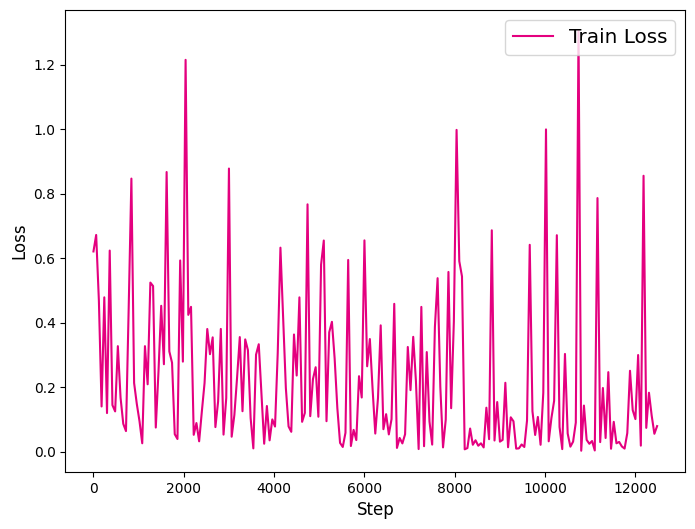

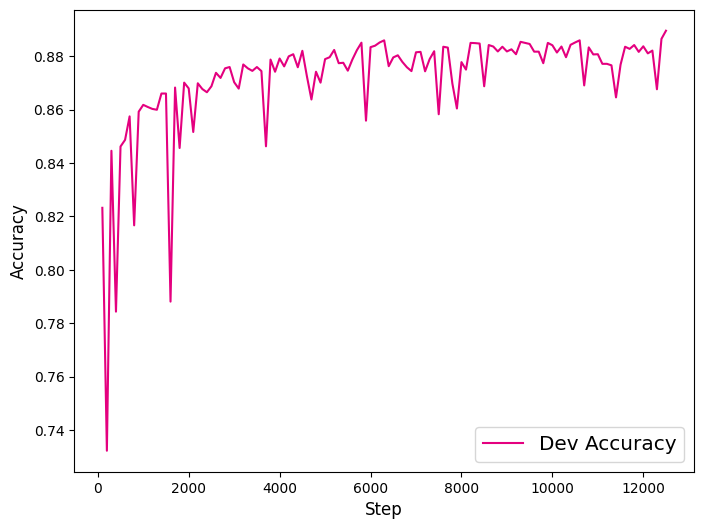

In [9]:
import matplotlib.pyplot as plt

def plot_training_loss(train_loss_record, fig_name, fig_size=(8, 6), sample_step=10, loss_legend_loc="lower left", acc_legend_loc="lower left"):
    plt.figure(figsize=fig_size)

    train_steps = [x[0] for x in train_loss_record][::sample_step]
    train_losses = [x[1] for x in train_loss_record][::sample_step]

    plt.plot(train_steps, train_losses, color='#e4007f', label="Train Loss")
    #绘制坐标轴和图例
    plt.ylabel("Loss", fontsize='large')
    plt.xlabel("Step", fontsize='large')
    plt.legend(loc=loss_legend_loc, fontsize='x-large')

    plt.savefig(fig_name)
    plt.show()

def plot_training_acc(train_score_record, fig_name, fig_size=(8, 6), sample_step=10, loss_legend_loc="lower left", acc_legend_loc="lower left"):
    plt.figure(figsize=fig_size)

    train_steps=[x[0] for x in train_score_record]
    train_losses = [x[1] for x in train_score_record]

    plt.plot(train_steps, train_losses, color='#e4007f', label="Dev Accuracy")
    #绘制坐标轴和图例
    plt.ylabel("Accuracy", fontsize='large')
    plt.xlabel("Step", fontsize='large')
    plt.legend(loc=loss_legend_loc, fontsize='x-large')

    plt.savefig(fig_name)
    plt.show()

fig_path = "./images/chapter7_bert_loss.pdf"
plot_training_loss(train_loss_record, fig_path, loss_legend_loc="upper right", sample_step=60)

fig_path = "./images/chapter7_bert_acc.pdf"
plot_training_acc(train_score_record, fig_path, sample_step=1, loss_legend_loc="lower right")

In [10]:
saved_state = paddle.load("./checkpoints/best.pdparams")
num_classes = 2
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_classes=num_classes)
model.load_dict(saved_state)

test_score = evaluate(model, test_loader, metric)
print(f"[Evaluate]  test score: {test_score:.5f}")

[2026-03-01 20:44:44,587] [    INFO] - We are using <class 'paddlenlp.transformers.bert.modeling.BertForSequenceClassification'> to load 'bert-base-uncased'.
[2026-03-01 20:44:44,588] [    INFO] - Already cached /home/ricaedo/.paddlenlp/models/bert-base-uncased/model_state.pdparams
[2026-03-01 20:44:44,588] [    INFO] - Loading weights file model_state.pdparams from cache at /home/ricaedo/.paddlenlp/models/bert-base-uncased/model_state.pdparams
[2026-03-01 20:44:46,752] [    INFO] - Loaded weights file from disk, setting weights to model.
[2026-03-01 20:44:46,815] [ WARNING] - Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForSequenceClassification: ['cls.predictions.decoder_bias', 'cls.predictions.decoder_weight', 'cls.predictions.layer_norm.bias', 'cls.predictions.layer_norm.weight', 'cls.predictions.transform.bias', 'cls.predictions.transform.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you 

[Evaluate]  test score: 0.88752


In [16]:
def infer(model, text):
    model.eval()
    encoded_inputs = tokenizer(text, max_seq_len=max_len)
    input_ids = paddle.to_tensor(encoded_inputs["input_ids"], dtype="int64").unsqueeze(0)
    token_type_ids = paddle.to_tensor(encoded_inputs["token_type_ids"], dtype="int64").unsqueeze(0)

    logits = model(input_ids=input_ids, token_type_ids=token_type_ids)

    id2label={0:"消极情绪", 1:"积极情绪"}
    max_label_id = paddle.argmax(logits, axis=1).numpy()[0]
    pred_label = id2label[max_label_id]
    print("Label: ", pred_label)

text = """
The Wandering Earth II is a spectacular,
thought-provoking sci-fi epic that outdoes its predecessor in scale and emotional depth, offering a, 
albeit slow-paced, deeply rewarding experience with top-tier visual effects
"""
"""
流浪地球2是一部规模宏大、引人深思的科幻史诗，
在规模和情感深度上超越了前作，
虽然节奏较慢，但提供了极具视觉效果的深度回报体验
"""
infer(model, text)

Label:  积极情绪


/home/ricaedo/下载/yes/envs/paddle/lib/python3.10/site-packages/paddlenlp/transformers/tokenizer_utils_base.py:2353: FutureWarning: The `max_seq_len` argument is deprecated and will be removed in a future version, please use `max_length` instead.
  warnings.warn(
